# Model Evaluation

Once we've collected a decent amount of data, the next logical question is: how good is our model at actually predicting uncertainty? We need a robust way to evaluate its performance before we start trusting it with live operational forecasts.

The first step, as always, is setting up our data pipeline. We need to load our raw inventory and split it into training and validation sets. A standard random split isn't usually the best choice for weather data due to temporal correlation (which can lead to data leakage), but our `Data().split_dataset()` method is designed to handle the chronological partitioning for us automatically.

In [1]:
from fue.config import Config
from fue.data import Data
from fue.models import MLUncertaintyModel

# Generate dataset
config = Config()
data = Data()
data.read_raw()
dataset = data.generate_dataset()

# Split data
train_df, val_df = data.split_dataset(dataset, val_fraction=0.2, random_state=42)
features = config.default_feature_columns
targets = config.default_target_columns

### Initialize the Neural Network Ensemble

Now that our data is prepped, we can initialize our uncertainty estimator. In this example, we'll use a Multi-Layer Perceptron (MLP) architecture. 

Because neural networks are highly sensitive to their random starting weights—meaning two identically configured models might converge to slightly different solutions—we use an ensemble approach. By training a small group of models (in this case, 5) and averaging their predictions, we smooth out that random initialization variance and get a much more stable, reliable prediction of the uncertainty bounds.

In [2]:
ml_model = MLUncertaintyModel(
    config=config,
    hidden_layer_sizes=(16, 8),
    max_iter=2000,
    alpha=0.01,
    ensemble_size=5,
)

### Perform a Convergence Study

Before we just fit the model on all our data and look at the final score, it's incredibly useful to understand *how* the model learns as we feed it more information. 

This is where a convergence study comes in. By training the model on progressively larger subsets of our training data (10%, 20%, 40%, etc.) and evaluating it against our holdout validation set at each step, we can plot a learning curve. 

Why do this? If the error curve is still trending sharply downward at 100%, it tells us we should probably keep running `fue download` because collecting more historical data will directly improve performance. If the curve has completely flattened out, our model has likely hit its capacity limits for this specific architecture, and more data won't help much without tuning the hyperparameters.

Running Convergence Study across 10549 training samples...


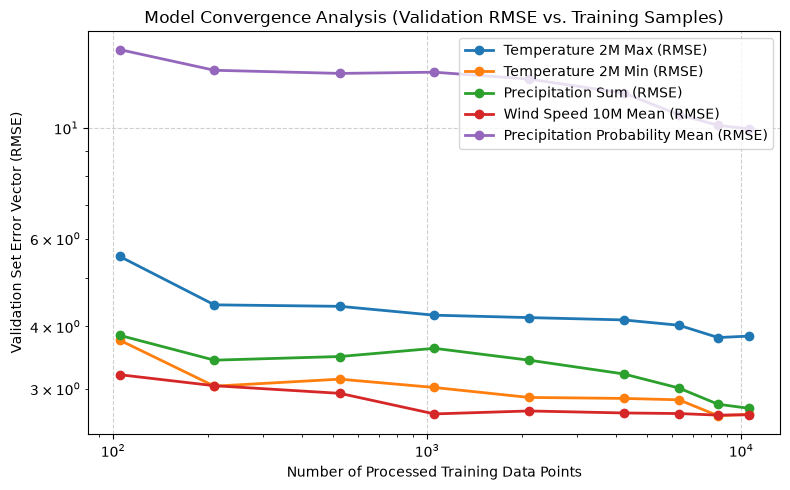

In [3]:
print(f"Running Convergence Study across {len(train_df)} training samples...")

# The study will train the model on 10%, 20%, 40%... up to 100% of the training data
# and record the validation metrics at each step.
convergence_results = ml_model.study_data_convergence(
    train_df=train_df,
    val_df=val_df,
    feature_columns=features,
    target_columns=targets,
    increments=[0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
)

# Render the learning curve for Root Mean Squared Error
ml_model.plot_learning_curve(convergence_history=convergence_results, metric="RMSE")

Finally, with our convergence study complete, we can train the model one last time using the entire training pool to ensure it has the maximum amount of information possible. 

Once fitted, we'll evaluate its predictive skill against the validation holdouts we set aside earlier. The output will give us the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) broken down by each meteorological target variable. This tabular summary provides a clear, quantitative baseline of our model's accuracy.

In [4]:
# 4. Final Evaluation Summary
# Fit the model on the full training pool one last time
ml_model.fit(train_df, feature_columns=features, target_columns=targets)

# Extract and print final metrics
final_metrics = ml_model.evaluate(val_df)
print("\n=== Final Validation Metrics ===")
for target, metrics in final_metrics.items():
    print(f"{target:<45} | MAE: {metrics['MAE']:.3f} | RMSE: {metrics['RMSE']:.3f}")


=== Final Validation Metrics ===
abs_diff__temperature_2m_max                  | MAE: 3.035 | RMSE: 3.823
abs_diff__temperature_2m_min                  | MAE: 2.111 | RMSE: 2.663
abs_diff__precipitation_sum                   | MAE: 1.414 | RMSE: 2.740
abs_diff__wind_speed_10m_mean                 | MAE: 2.073 | RMSE: 2.659
abs_diff__precipitation_probability_mean      | MAE: 6.015 | RMSE: 9.960
